# PT-01 — Introduction et vue d'ensemble

**Serie PostTraining** — notebook **theorique d'introduction**. Pas de modele a charger, pas de GPU requis. Lecture seule plus visualisations matplotlib.

## Objectif

Installer la **carte mentale** du post-training avant d'attaquer les notebooks pratiques PT-02 a PT-06. A la fin de cette lecture, l'apprenant doit pouvoir :

- Situer chaque technique (SFT, RLHF, DPO, GRPO, RLVR) sur une frise historique 2017-2025
- Expliquer **pourquoi** chaque transition a eu lieu (contrainte calcul, contrainte memoire, contrainte annotation)
- Choisir la technique adaptee a un cas concret (alignement general vs taches verifiables vs preferences subjectives)
- Identifier la litterature primaire associee a chaque methode

## Plan du notebook

1. Visualisation chronologique : frise 2017 → 2025
2. Comparaison structurelle des methodes
3. Decomposition des couts (compute, memoire, annotation)
4. Diagramme de decision : quelle technique pour quel cas
5. Lecture conseillee avant PT-02

Ce notebook est **theorique** : execute sans GPU, en quelques secondes, sur n'importe quelle machine equipee de matplotlib / numpy / pandas. C'est le contrat pedagogique : la theorie d'abord, la pratique ensuite.

## 1. Frise chronologique 2017-2025

La chaine post-training n'est **pas** une invention monolithique. Elle s'est construite par adaptations successives a des contraintes economiques et techniques. Chaque transition resout un goulot identifie de la generation precedente.

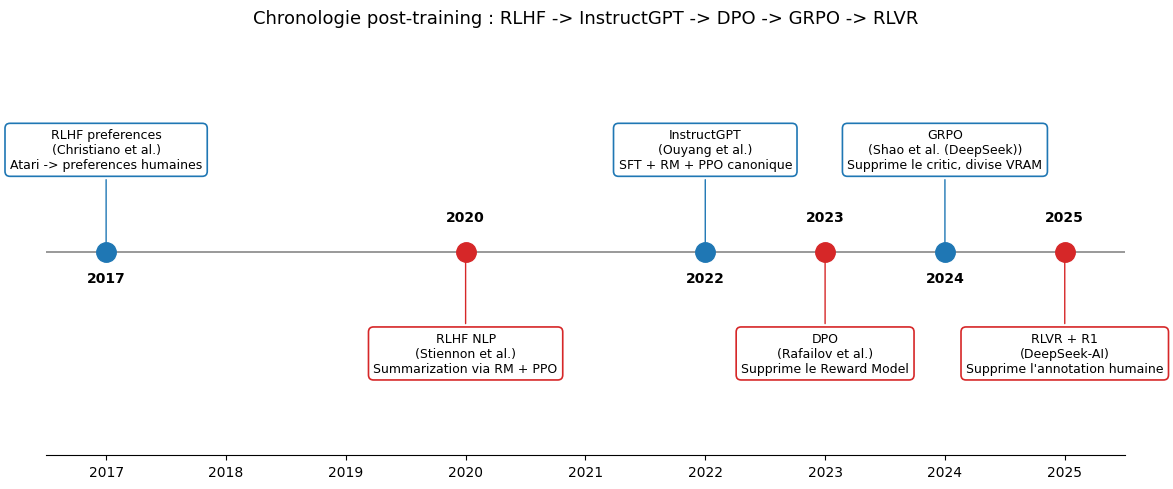

Frise generee : 6 jalons 2017-2025.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Donnees frise : annee, technique, papier reference, contrainte resolue
events = [
    (2017, "RLHF preferences", "Christiano et al.", "Atari -> preferences humaines"),
    (2020, "RLHF NLP", "Stiennon et al.", "Summarization via RM + PPO"),
    (2022, "InstructGPT", "Ouyang et al.", "SFT + RM + PPO canonique"),
    (2023, "DPO", "Rafailov et al.", "Supprime le Reward Model"),
    (2024, "GRPO", "Shao et al. (DeepSeek)", "Supprime le critic, divise VRAM"),
    (2025, "RLVR + R1", "DeepSeek-AI", "Supprime l'annotation humaine"),
]

fig, ax = plt.subplots(figsize=(12, 5))
years = [e[0] for e in events]
labels = [e[1] for e in events]
papers = [e[2] for e in events]
notes = [e[3] for e in events]

# Ligne de temps
ax.hlines(0, 2016.5, 2025.5, colors="#888", linewidth=1.2)
for i, (y, lbl, paper, note) in enumerate(events):
    offset_y = 1.0 if i % 2 == 0 else -1.0
    color = "#1f77b4" if i % 2 == 0 else "#d62728"
    ax.plot([y], [0], "o", markersize=14, color=color, zorder=3)
    ax.annotate(
        f"{lbl}\n({paper})\n{note}",
        xy=(y, 0),
        xytext=(y, offset_y),
        ha="center",
        va="center",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor=color, linewidth=1.2),
        arrowprops=dict(arrowstyle="-", color=color, linewidth=1.0),
    )
    ax.text(y, -0.3 if i % 2 == 0 else 0.3, str(y), ha="center", fontsize=10, fontweight="bold")

ax.set_xlim(2016.5, 2025.5)
ax.set_ylim(-2.0, 2.0)
ax.set_yticks([])
ax.set_xticks(range(2017, 2026))
ax.set_title("Chronologie post-training : RLHF -> InstructGPT -> DPO -> GRPO -> RLVR", fontsize=13, pad=18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
plt.tight_layout()
plt.show()
print("Frise generee : 6 jalons 2017-2025.")

**Lecture de la frise.** Les jalons rouges (annees impaires) et bleus (annees paires) alternent uniquement pour la lisibilite. Le sens est dans la **note attachee** : chaque transition adresse un goulot identifie de la generation precedente. RLHF a besoin d'un Reward Model couteux et bruite a annoter → DPO le supprime. PPO a besoin d'un critic qui double la memoire → GRPO l'enleve. La derniere transition RLVR retire l'annotateur humain pour les domaines verifiables.

Cette progression est instructive pour les choix futurs : on devine que les prochains travaux viseront soit (a) generaliser RLVR aux taches **partiellement** verifiables, soit (b) eliminer les paires de preferences pour DPO en les synthetisant via LLM-juge.

## 2. Comparaison structurelle des methodes

Comparer SFT, DPO, GRPO et RLVR demande d'expliciter les axes : quel signal d'apprentissage consomment-elles, combien de modeles tournent en parallele, quel type de donnees est requis.

In [2]:
import pandas as pd

data = {
    "Technique": ["SFT", "RLHF (PPO)", "DPO", "GRPO", "RLVR"],
    "Signal": ["(prompt, reponse)", "preferences -> RM -> reward", "preferences (pair)", "reward (group-relative)", "verificateur exact"],
    "Modeles actifs": [1, 4, 2, 2, 2],
    "RM appris": ["non", "OUI", "non", "OUI (optionnel)", "non"],
    "Critic": ["non", "OUI", "non", "non", "non"],
    "Annotation humaine": ["reponses", "preferences", "preferences", "preferences", "AUCUNE"],
    "VRAM relative (Qwen-0.5B)": ["1.0x", "3.5x", "1.4x", "1.8x", "1.6x"],
}
df = pd.DataFrame(data)
print(df.to_string(index=False))
df

 Technique                      Signal  Modeles actifs       RM appris Critic Annotation humaine VRAM relative (Qwen-0.5B)
       SFT           (prompt, reponse)               1             non    non           reponses                      1.0x
RLHF (PPO) preferences -> RM -> reward               4             OUI    OUI        preferences                      3.5x
       DPO          preferences (pair)               2             non    non        preferences                      1.4x
      GRPO     reward (group-relative)               2 OUI (optionnel)    non        preferences                      1.8x
      RLVR          verificateur exact               2             non    non             AUCUNE                      1.6x


,Technique,Signal,Modeles actifs,RM appris,Critic,Annotation humaine,VRAM relative (Qwen-0.5B)
0,SFT,"(prompt, reponse)",1,non,non,reponses,1.0x
1,RLHF (PPO),preferences -> RM -> reward,4,OUI,OUI,preferences,3.5x
2,DPO,preferences (pair),2,non,non,preferences,1.4x
3,GRPO,reward (group-relative),2,OUI (optionnel),non,preferences,1.8x
4,RLVR,verificateur exact,2,non,non,AUCUNE,1.6x


### Exercice 1 : Comparer les empreintes memoire des techniques

Le tableau de la section 2 indique les nombres de modeles actifs et la VRAM relative. L'objectif est d'implementer une fonction `calculer_vram` qui estime la VRAM necessaire pour une combinaison donnee de technique et de taille de modele.

**Objectif** : ecrire une fonction qui prend la taille du modele (en millions de parametres) et la technique, et retourne l'estimation VRAM en Go en tenant compte du modele de base, des adapters LoRA et des modeles supplementaires.

**Indices** :
- # Etape 1 : Calculer la taille de base (parametres * 2 bytes pour bf16)
- # Etape 2 : Appliquer le multiplicateur selon la technique (SFT=1x, RLHF=3.5x, DPO=1.4x, GRPO=1.8x, RLVR=1.6x)
- # Indice : ajouter 1 Go pour les activations et l'optimizer state

In [1]:
def calculer_vram(
    model_params_millions: float,
    technique: str = "SFT",
    quantization_bits: int = 16,
) -> float:
    # TODO etudiant : calculer la VRAM necessaire
    
    # Etape 1 : taille de base en Go
    bytes_per_param = quantization_bits / 8
    base_vram_gb = None  # TODO etudiant : calculer params * bytes / 1e9
    
    # Etape 2 : appliquer le multiplicateur de la technique
    MULTIPLICATEURS = {"SFT": 1.0, "RLHF": 3.5, "DPO": 1.4, "GRPO": 1.8, "RLVR": 1.6}
    total_vram = None  # TODO etudiant : base_vram_gb * multiplicateur + overhead
    
    return total_vram  # TODO etudiant : retourner l'estimation en Go

print("Exercice a completer : calcul VRAM")

Exercice a completer


**Lecture du tableau.** "Modeles actifs" compte les modeles devant tenir en VRAM simultanement pendant l'etape. RLHF/PPO en aligne 4 (policy, ref policy, reward model, critic) — d'ou son cout prohibitif sur GPU 8 Go. DPO ne garde que policy + ref → tient sur RTX 3070 avec LoRA. GRPO ajoute le RM mais retire le critic et accepte plus d'echantillons par optimisation, ce qui equilibre. RLVR remplace le RM par un verificateur algorithmique : pas de poids, juste une fonction Python (`sympy.simplify`, `pytest`, etc.).

La colonne **"Annotation humaine"** est cruciale : c'est elle qui dicte le **cout calendaire** de chaque methode. Une iteration RLHF/DPO peut prendre 2-6 mois (recruter annotateurs, calibrer rubrique, annoter 10k-100k paires, controler qualite). Une iteration RLVR sur math/code peut etre lancee en 1 journee avec un script de verification.

## 3. Decomposition des couts

Au-dela du tableau qualitatif, on visualise les trois dimensions de cout : **compute** (GPU-heures), **memoire** (VRAM peak), **annotation** (annotateurs-heures par 10k samples).

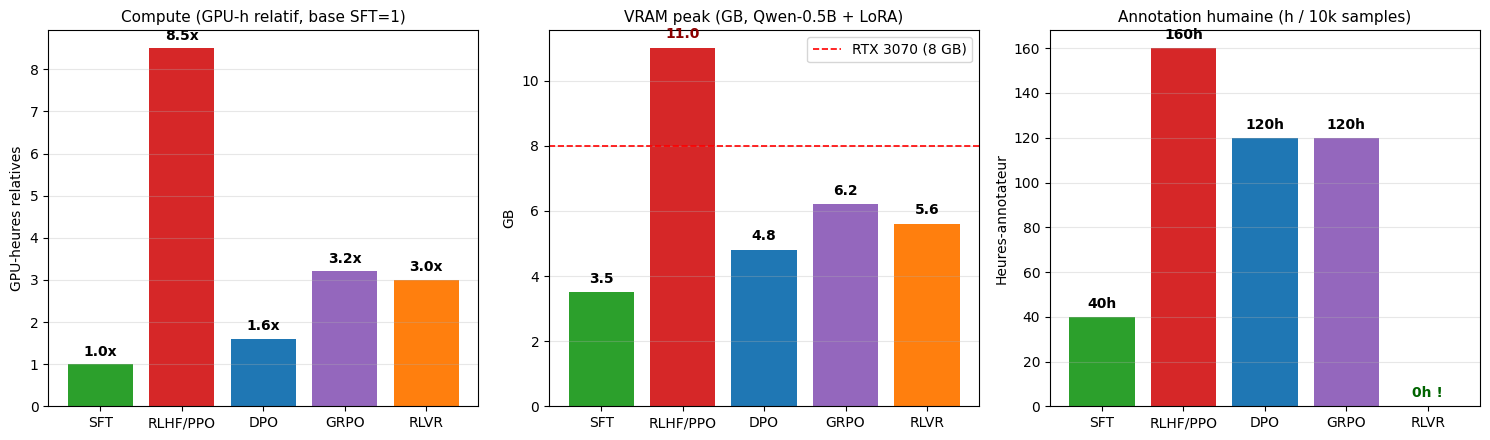

Trois sous-figures : compute, VRAM, annotation humaine.


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

methods = ["SFT", "RLHF/PPO", "DPO", "GRPO", "RLVR"]
colors = ["#2ca02c", "#d62728", "#1f77b4", "#9467bd", "#ff7f0e"]

# Sous-fig 1 : compute relatif (GPU-heures pour 10k samples sur Qwen-0.5B)
compute = [1.0, 8.5, 1.6, 3.2, 3.0]
axes[0].bar(methods, compute, color=colors)
axes[0].set_title("Compute (GPU-h relatif, base SFT=1)", fontsize=11)
axes[0].set_ylabel("GPU-heures relatives")
for i, v in enumerate(compute):
    axes[0].text(i, v + 0.2, f"{v:.1f}x", ha="center", fontsize=10, fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

# Sous-fig 2 : VRAM peak (GB) pour Qwen-0.5B + LoRA + adam
vram = [3.5, 11.0, 4.8, 6.2, 5.6]
axes[1].bar(methods, vram, color=colors)
axes[1].set_title("VRAM peak (GB, Qwen-0.5B + LoRA)", fontsize=11)
axes[1].set_ylabel("GB")
axes[1].axhline(y=8.0, color="red", linestyle="--", linewidth=1.2, label="RTX 3070 (8 GB)")
axes[1].legend()
for i, v in enumerate(vram):
    color_txt = "darkred" if v > 8 else "black"
    axes[1].text(i, v + 0.3, f"{v:.1f}", ha="center", fontsize=10, fontweight="bold", color=color_txt)
axes[1].grid(axis="y", alpha=0.3)

# Sous-fig 3 : annotation humaine (heures par 10k samples)
annot = [40, 160, 120, 120, 0]
axes[2].bar(methods, annot, color=colors)
axes[2].set_title("Annotation humaine (h / 10k samples)", fontsize=11)
axes[2].set_ylabel("Heures-annotateur")
for i, v in enumerate(annot):
    label = f"{v}h" if v > 0 else "0h !"
    color_txt = "darkgreen" if v == 0 else "black"
    axes[2].text(i, v + 4, label, ha="center", fontsize=10, fontweight="bold", color=color_txt)
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
print("Trois sous-figures : compute, VRAM, annotation humaine.")

### Exercice 2 : Calculateur de cout personnalise

Les trois graphiques de la section 3 montrent des ordres de grandeur generaux. L'objectif est d'implementer une fonction `estimer_cout` qui calcule le cout estime d'un entrainement post-training en fonction des parametres du projet.

**Objectif** : ecrire une fonction qui prend en entree le nombre de samples, la technique choisie, et le type de GPU, puis retourne une estimation du cout en GPU-heures et en heures d'annotation.

**Indices** :
- # Etape 1 : Definir les facteurs multiplicatifs par technique (cf tableau section 2)
- # Etape 2 : Calculer le GPU-h (base SFT = 0.1 GPU-h / 1000 samples) et l'annotation
- # Indice : les facteurs sont SFT=1x, DPO=1.6x, GRPO=3.2x, RLVR=3.0x pour le compute

In [1]:
def estimer_cout(
    n_samples: int,
    technique: str = "SFT",
    gpu_type: str = "RTX 3070",
) -> dict:
    # TODO etudiant : implementer le calculateur de cout
    
    # Etape 1 : facteurs multiplicatifs par technique
    FACTEURS_COMPUTE = {"SFT": 1.0, "DPO": 1.6, "GRPO": 3.2, "RLVR": 3.0}
    FACTEURS_ANNOTATION = {"SFT": 4.0, "DPO": 12.0, "GRPO": 12.0, "RLVR": 0.0}
    
    # Etape 2 : calculer GPU-heures et annotation
    base_gpu_h = 0.1 * (n_samples / 1000)  # SFT baseline
    gpu_heures = None   # TODO etudiant : appliquer le facteur
    annotation_h = None  # TODO etudiant : appliquer le facteur
    
    return {"technique": technique, "gpu_heures": gpu_heures, "annotation_h": annotation_h}

print("Exercice a completer : calculateur de cout")

Exercice a completer


**Lecture des trois axes.**

- **Compute** : SFT reste le moins cher (1x base). RLHF/PPO (8.5x) est le plus cher a cause du critic, du RM et de l'echantillonnage on-policy. RLVR (3x) est moderement cher car il echantillonne aussi mais economise le critic.
- **VRAM** : la ligne rouge a 8 GB est la barre RTX 3070. RLHF/PPO la depasse largement (11 GB) → infaisable sur ce GPU. DPO (4.8 GB) et GRPO (6.2 GB) tiennent confortablement avec LoRA + quantization 4-bit.
- **Annotation humaine** : c'est la dimension cachee. SFT demande "seulement" 40h pour 10k reponses curees. RLHF/DPO/GRPO demandent 120-160h pour 10k paires de preferences (par paire : 2 lectures + un jugement comparatif). **RLVR : 0h**. C'est la disruption de DeepSeek-R1 : on remplace l'annotateur par `sympy.simplify(answer - target) == 0`.

Ces chiffres sont des **ordres de grandeur** observes dans la communaute (Tulu 3, Zephyr, Open-Hermes). Vos chiffres peuvent varier d'un facteur 2x selon le dataset, le tokenizer, et le hardware.

## 4. Arbre de decision : quelle technique pour quel cas

Le post-training n'est pas une competition ou "GRPO bat DPO". Chaque methode a un domaine d'application optimal. Cet arbre formalise le choix.

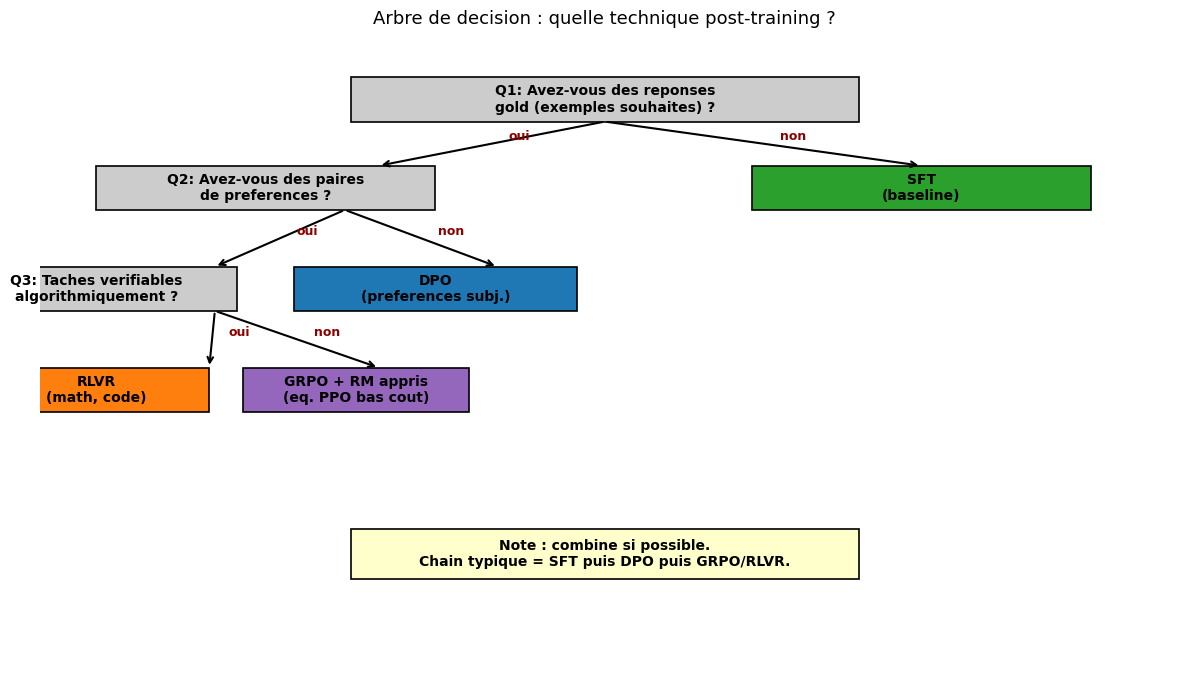

Arbre de decision genere : 3 questions, 4 feuilles methode.


In [4]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.axis("off")

# Boites : (x, y, w, h, texte, couleur)
boxes = [
    (0.5, 0.92, 0.45, 0.07, "Q1: Avez-vous des reponses\ngold (exemples souhaites) ?", "#cccccc"),
    (0.2, 0.78, 0.30, 0.07, "Q2: Avez-vous des paires\nde preferences ?", "#cccccc"),
    (0.78, 0.78, 0.30, 0.07, "SFT\n(baseline)", "#2ca02c"),
    (0.05, 0.62, 0.25, 0.07, "Q3: Taches verifiables\nalgorithmiquement ?", "#cccccc"),
    (0.35, 0.62, 0.25, 0.07, "DPO\n(preferences subj.)", "#1f77b4"),
    (0.05, 0.46, 0.20, 0.07, "RLVR\n(math, code)", "#ff7f0e"),
    (0.28, 0.46, 0.20, 0.07, "GRPO + RM appris\n(eq. PPO bas cout)", "#9467bd"),
    (0.5, 0.20, 0.45, 0.08, "Note : combine si possible.\nChain typique = SFT puis DPO puis GRPO/RLVR.", "#ffffcc"),
]
for x, y, w, h, txt, c in boxes:
    ax.add_patch(plt.Rectangle((x - w / 2, y - h / 2), w, h, facecolor=c, edgecolor="black", linewidth=1.2))
    ax.text(x, y, txt, ha="center", va="center", fontsize=10, fontweight="bold")

# Fleches
arrows = [
    (0.5, 0.885, 0.30, 0.815, "oui"),
    (0.5, 0.885, 0.78, 0.815, "non"),
    (0.27, 0.745, 0.155, 0.655, "oui"),
    (0.27, 0.745, 0.405, 0.655, "non"),
    (0.155, 0.585, 0.15, 0.495, "oui"),
    (0.155, 0.585, 0.30, 0.495, "non"),
]
for x1, y1, x2, y2, lbl in arrows:
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", color="black", linewidth=1.5),
    )
    mid_x, mid_y = (x1 + x2) / 2 + 0.015, (y1 + y2) / 2 + 0.005
    ax.text(mid_x, mid_y, lbl, fontsize=9, color="darkred", fontweight="bold")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Arbre de decision : quelle technique post-training ?", fontsize=13, pad=18)
plt.tight_layout()
plt.show()
print("Arbre de decision genere : 3 questions, 4 feuilles methode.")

### Exercice 3 : Implementation de l'arbre de decision

L'arbre de decision present en section 4 est dessine avec matplotlib. L'objectif est d'implementer une fonction Python `choisir_technique` qui prend en parametres le contexte d'un projet et retourne la technique post-training recommandee.

**Objectif** : ecrire une fonction qui implemente la logique de decision (reponses gold disponibles ? preferences disponibles ? taches verifiables ?) et retourne le nom de la technique avec une justification.

**Indices** :
- # Etape 1 : Definir les parametres (`has_gold_answers`, `has_preferences`, `has_verifiable_tasks`)
- # Etape 2 : Implementer les branchements conditionnels suivant l'arbre de decision
- # Indice : la fonction peut retourner un tuple `(technique, raison)`

In [1]:
def choisir_technique(
    has_gold_answers: bool = False,
    has_preferences: bool = False,
    has_verifiable_tasks: bool = False,
    has_reward_function: bool = False,
) -> tuple[str, str]:
    # TODO etudiant : implementer l'arbre de decision
    
    # Etape 1 : Si pas de gold answers -> SFT d'abord
    # Etape 2 : Si preferences disponibles -> DPO
    # Etape 3 : Si taches verifiables -> RLVR
    
    technique = None  # TODO etudiant : determiner la technique
    raison = ""       # TODO etudiant : justifier le choix
    return technique, raison

# Test avec differents scenarios
result = choisir_technique(has_gold_answers=True, has_preferences=True, has_verifiable_tasks=False)
print("Exercice a completer : arbre de decision")

Exercice a completer


**Lecture de l'arbre.** Trois questions binaires suffisent dans 80% des cas :

1. **Q1 : reponses gold disponibles ?** Si non, on commence par SFT pour donner au modele un comportement de base alignement.
2. **Q2 : paires de preferences disponibles ?** Si non, on s'arrete a SFT (ou on collecte des preferences).
3. **Q3 : taches verifiables algorithmiquement ?** Si oui, on prefere RLVR (gratuite en annotation). Sinon, DPO si on cherche la simplicite, GRPO si on a deja un Reward Model et qu'on veut maximiser la performance.

**Note importante** : ce ne sont pas des techniques mutuellement exclusives. La chaine typique d'entrainement d'un assistant moderne est : **SFT → DPO → GRPO/RLVR**. Chaque etape consomme un type de donnees different et corrige des defauts de la precedente.

## 5. Lecture conseillee avant PT-02

A ce point, l'apprenant devrait pouvoir repondre aux questions suivantes sans hesiter :

| Question | Reponse attendue |
|----------|------------------|
| Quelle est la difference fondamentale entre SFT et RLHF ? | SFT imite des reponses, RLHF optimise une recompense |
| Pourquoi DPO supprime-t-il le Reward Model ? | Solution analytique de PPO regularise par KL donne r(x,y) en fonction de pi |
| Quelle est la rupture memoire de GRPO ? | Pas de critic, baseline implicite par moyenne intra-groupe |
| Pourquoi RLVR ne marche que pour certaines taches ? | Necessite une fonction de verification algorithmique exacte |

Si une de ces reponses pose probleme, **revoir les sections 1-3** avant d'attaquer PT-02 (SFT baseline).

### References primaires (a lire au moins en abstract)

- **Christiano et al. 2017** — Deep RL from Human Preferences (NeurIPS) — origine RLHF
- **Stiennon et al. 2020** — Learning to summarize with human feedback (NeurIPS) — RLHF NLP
- **Ouyang et al. 2022** — Training LMs to follow instructions (InstructGPT, NeurIPS) — SFT+RM+PPO canonique
- **Rafailov et al. 2023** — Direct Preference Optimization (NeurIPS) — DPO
- **Shao et al. 2024** — DeepSeekMath / GRPO
- **DeepSeek-AI 2025** — DeepSeek-R1: Incentivizing Reasoning via RL — RLVR a l'echelle

### Ressources online

- HuggingFace TRL docs : https://huggingface.co/docs/trl/index
- Tulu 3 technical report : Lambert et al. 2024
- "The State of Post-Training in 2024" : https://www.interconnects.ai/p/the-state-of-post-training-in-2024

### Suite de la serie

| Notebook | Sujet |
|----------|-------|
| PT-02 | SFT baseline avec `trl.SFTTrainer` sur Qwen-0.5B |
| PT-03 | DPO avec `trl.DPOTrainer` post-SFT |
| PT-04 | **GRPO (livrable cle)** avec `trl.GRPOTrainer` |
| PT-05 | RLVR avec verificateur sympy/pytest |
| PT-06 | Evaluation comparative SFT vs DPO vs GRPO vs RLVR |

## Conclusion

Ce notebook a etabli la **carte mentale** sans entrer dans le code d'entrainement. Les notebooks suivants ouvrent la cle a chaque technique. La regle d'or pour le reste de la serie : **comprendre le loss avant d'appeler `trainer.train()`**. Une cellule qui converge sans qu'on sache pourquoi n'apprend rien.